# NYC Taxi Trip Duration - Data Exploration & Preprocessing

Ce notebook explore et prépare les données pour la prédiction de la durée des trajets en taxi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src to path
sys.path.insert(0, '..')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Chargement des données prétraitées

In [2]:
# Chemins
processed_data_path = Path('../data/processed')

# Charger les données prétraitées
print("Chargement des données prétraitées...")
train_raw = pd.read_csv(processed_data_path / 'train_processed.csv')
test_raw = pd.read_csv(processed_data_path / 'test_processed.csv')

print(f"\nTrain data shape: {train_raw.shape}")
print(f"Test data shape: {test_raw.shape}")
print(f"\nTrain data info:")
print(train_raw.info())

Chargement des données prétraitées...

Train data shape: (1456886, 21)
Test data shape: (625134, 19)

Train data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456886 entries, 0 to 1456885
Data columns (total 21 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1456886 non-null  object 
 1   vendor_id           1456886 non-null  int64  
 2   pickup_datetime     1456886 non-null  object 
 3   dropoff_datetime    1456886 non-null  object 
 4   passenger_count     1456886 non-null  int64  
 5   pickup_longitude    1456886 non-null  float64
 6   pickup_latitude     1456886 non-null  float64
 7   dropoff_longitude   1456886 non-null  float64
 8   dropoff_latitude    1456886 non-null  float64
 9   store_and_fwd_flag  1456886 non-null  object 
 10  trip_duration       1456886 non-null  int64  
 11  year                1456886 non-null  int64  
 12  month               1456886 non-null  int64  
 13

## 2. Aperçu des données

In [3]:
print("="*60)
print("APERÇU DES DONNÉES TRAIN")
print("="*60)
print(train_raw.head(10))
print("\nDescriptif statistique:")
print(train_raw.describe())

APERÇU DES DONNÉES TRAIN
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   
5  id0801584          2  2016-01-30 22:01:40  2016-01-30 22:09:03   
6  id1813257          1  2016-06-17 22:34:59  2016-06-17 22:40:40   
7  id1324603          2  2016-05-21 07:54:58  2016-05-21 08:20:49   
8  id1301050          1  2016-05-27 23:12:23  2016-05-27 23:16:38   
9  id0012891          2  2016-03-10 21:45:01  2016-03-10 22:05:26   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564         -

## 3. Valeurs manquantes et doublons

In [4]:
print("Valeurs manquantes:")
print(train_raw.isnull().sum())
print(f"\nDoublons: {train_raw.duplicated().sum()}")

Valeurs manquantes:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
year                  0
month                 0
day                   0
hour                  0
minute                0
day_of_week           0
distance              0
manhattan_distance    0
direction_ns          0
direction_ew          0
dtype: int64

Doublons: 0


## 4. Analyse de la variable cible (trip_duration)

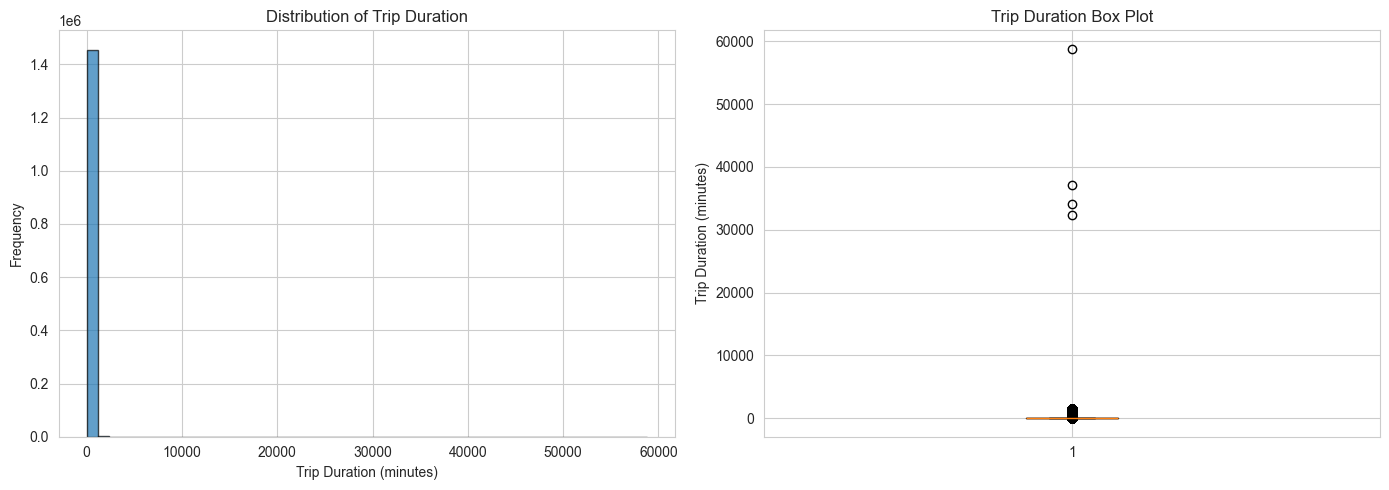


Trip Duration Statistics (en secondes):
count    1.456886e+06
mean     9.578572e+02
std      5.237098e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.074000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

Trip Duration Statistics (en minutes):
count    1.456886e+06
mean     1.596429e+01
std      8.728496e+01
min      1.666667e-02
25%      6.616667e+00
50%      1.103333e+01
75%      1.790000e+01
max      5.877137e+04
Name: trip_duration, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(train_raw['trip_duration'] / 60, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Trip Duration (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Trip Duration')

# Box plot
axes[1].boxplot(train_raw['trip_duration'] / 60)
axes[1].set_ylabel('Trip Duration (minutes)')
axes[1].set_title('Trip Duration Box Plot')

plt.tight_layout()
plt.show()

print(f"\nTrip Duration Statistics (en secondes):")
print(train_raw['trip_duration'].describe())
print(f"\nTrip Duration Statistics (en minutes):")
print((train_raw['trip_duration'] / 60).describe())

## 5. Features après prétraitement

In [6]:
print("="*60)
print("APERÇU DES DONNÉES PRÉTRAITÉES")
print("="*60)
print(train_raw.head(10))
print("\nColonnes créées par le prétraitement:")
print(train_raw.columns.tolist())

APERÇU DES DONNÉES PRÉTRAITÉES
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   
5  id0801584          2  2016-01-30 22:01:40  2016-01-30 22:09:03   
6  id1813257          1  2016-06-17 22:34:59  2016-06-17 22:40:40   
7  id1324603          2  2016-05-21 07:54:58  2016-05-21 08:20:49   
8  id1301050          1  2016-05-27 23:12:23  2016-05-27 23:16:38   
9  id0012891          2  2016-03-10 21:45:01  2016-03-10 22:05:26   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.738564    

## 6. Exploration des features importantes

In [7]:
train_processed = train_raw

print("\nColonnes après prétraitement:")
print(train_processed.columns.tolist())

print("\nAperçu des données prétraitées:")
print(train_processed.head())

print("\nTypes de données:")
print(train_processed.dtypes)


Colonnes après prétraitement:
['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'year', 'month', 'day', 'hour', 'minute', 'day_of_week', 'distance', 'manhattan_distance', 'direction_ns', 'direction_ew']

Aperçu des données prétraitées:
          id  vendor_id      pickup_datetime     dropoff_datetime  \
0  id2875421          2  2016-03-14 17:24:55  2016-03-14 17:32:30   
1  id2377394          1  2016-06-12 00:43:35  2016-06-12 00:54:38   
2  id3858529          2  2016-01-19 11:35:24  2016-01-19 12:10:48   
3  id3504673          2  2016-04-06 19:32:31  2016-04-06 19:39:40   
4  id2181028          2  2016-03-26 13:30:55  2016-03-26 13:38:10   

   passenger_count  pickup_longitude  pickup_latitude  dropoff_longitude  \
0                1        -73.982155        40.767937         -73.964630   
1                1        -73.980415        40.73

## 7. Corrélation avec la variable cible

Top 10 features les plus corrélées:
trip_duration         1.000000
distance              0.102696
manhattan_distance    0.101228
pickup_longitude      0.049123
dropoff_longitude     0.028311
vendor_id             0.020247
passenger_count       0.008495
month                 0.006556
direction_ns          0.004951
hour                  0.003670
day                   0.000565
Name: trip_duration, dtype: float64


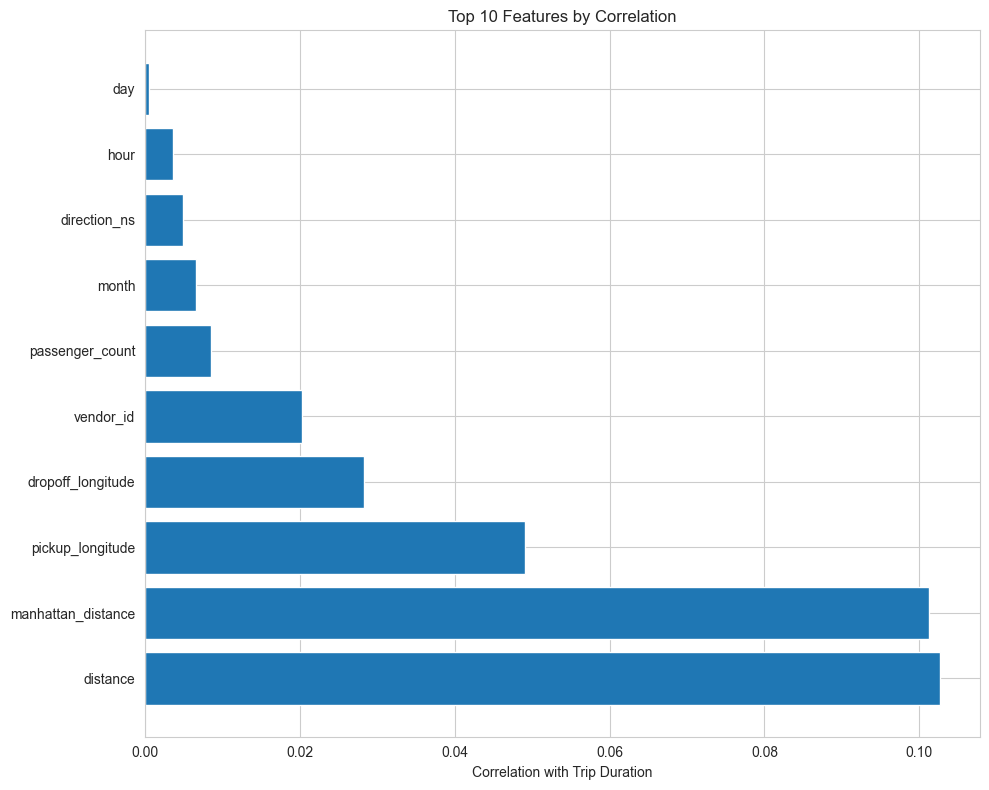

In [8]:
# Calculer les corrélations sur les colonnes numériques uniquement
numeric_train_processed = train_processed.select_dtypes(include=[np.number])
correlations = numeric_train_processed.corr()['trip_duration'].sort_values(ascending=False)

print("Top 10 features les plus corrélées:")
print(correlations.head(11))  # +1 pour inclure trip_duration lui-même

# Visualisation
plt.figure(figsize=(10, 8))
top_features = correlations.drop('trip_duration').head(10)
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation with Trip Duration')
plt.title('Top 10 Features by Correlation')
plt.tight_layout()
plt.show()

## 8. Variables temporelles


Trip Duration par heure du jour:
             mean  median  count
hour                            
0      935.486056   645.0  53142
1      901.396991   613.0  38487
2      887.962921   591.0  27913
3      887.996785   592.0  20843
4      915.551575   610.0  15744
5      821.354199   517.0  14969
6      796.100921   473.0  33214
7      828.895170   574.0  55547
8      923.527013   660.0  67006
9      933.083994   680.0  67612
10     932.911977   679.0  65392
11     965.694151   703.0  68426
12     992.412839   706.0  71815
13    1030.174188   710.0  71417
14    1074.509074   726.0  74221
15    1117.042541   719.0  71742
16    1077.264490   695.0  64252
17    1029.015590   700.0  76396
18     979.564601   686.0  90510
19     893.490923   648.0  90226
20     877.047294   634.0  83964
21     887.968604   641.0  84055
22    1021.917639   667.0  80341
23     923.505929   669.0  69652


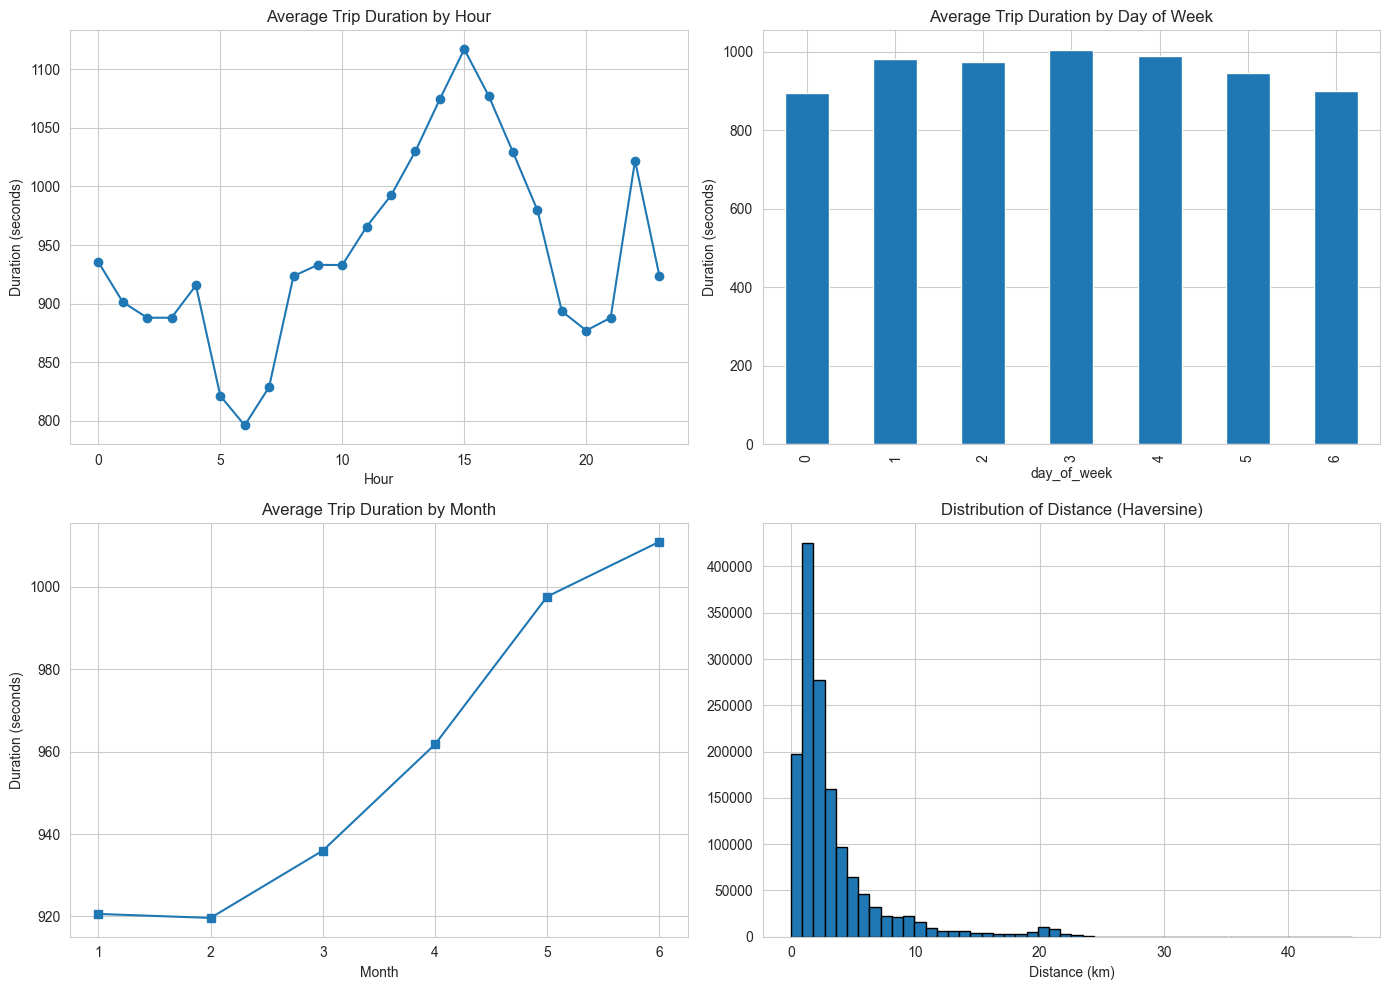

In [9]:
# Analyse par heure
hour_stats = train_processed.groupby('hour')['trip_duration'].agg(['mean', 'median', 'count'])
print("\nTrip Duration par heure du jour:")
print(hour_stats)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
train_processed.groupby('hour')['trip_duration'].mean().plot(ax=ax, marker='o')
ax.set_title('Average Trip Duration by Hour')
ax.set_xlabel('Hour')
ax.set_ylabel('Duration (seconds)')

ax = axes[0, 1]
train_processed.groupby('day_of_week')['trip_duration'].mean().plot(ax=ax, kind='bar')
ax.set_title('Average Trip Duration by Day of Week')
ax.set_ylabel('Duration (seconds)')

ax = axes[1, 0]
train_processed.groupby('month')['trip_duration'].mean().plot(ax=ax, marker='s')
ax.set_title('Average Trip Duration by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Duration (seconds)')

ax = axes[1, 1]
train_processed['distance'].hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribution of Distance (Haversine)')
ax.set_xlabel('Distance (km)')

plt.tight_layout()
plt.show()

## 9. Sauvegarde des données prétraitées

In [10]:
# Vérifier si déjà sauvegardées
train_file = processed_data_path / 'train_processed.csv'
test_file = processed_data_path / 'test_processed.csv'

if train_file.exists() and test_file.exists():
    print("✓ Données prétraitées déjà sauvegardées")
else:
    preprocessor.save_processed_data(train_processed, 'train_processed.csv')
    preprocessor.save_processed_data(test_processed, 'test_processed.csv')
    print("✓ Données prétraitées sauvegardées")

✓ Données prétraitées déjà sauvegardées
